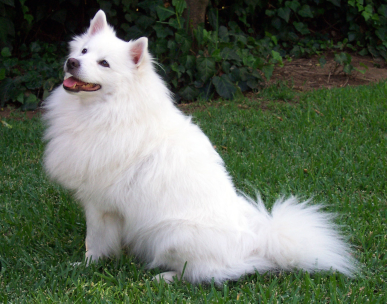

In [1]:
import matplotlib.pyplot as plt
import urllib
from PIL import Image

url = "https://github.com/pytorch/hub/raw/master/images/dog.jpg"
file = "dog.jpg"
urllib.request.urlretrieve(url, file)
img = Image.open(file).convert("RGB")
img.reduce(4)

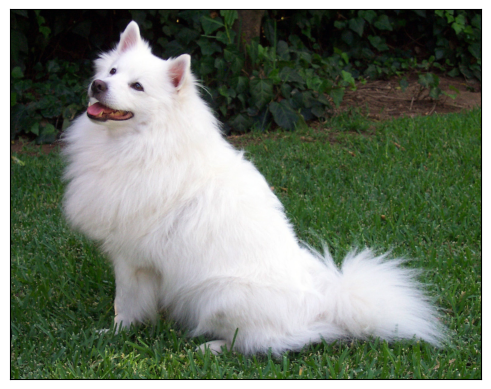

In [2]:
import torch
from torchvision.transforms import v2

transforms = v2.Compose([v2.ToImage(), v2.ToDtype(torch.uint8, scale=True)])
out = transforms(img)
plt.xticks([])
plt.yticks([])
plt.imshow(out.permute(1, 2, 0).numpy())

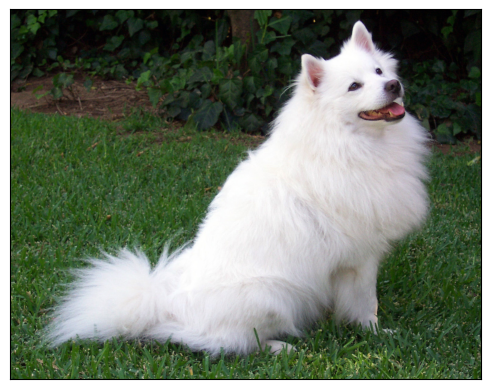

In [4]:
transforms = v2.Compose(
    [v2.ToImage(), v2.ToDtype(torch.uint8, scale=True), v2.RandomHorizontalFlip(p=1.0)]
)
out = transforms(img)
plt.xticks([])
plt.yticks([])
plt.imshow(out.permute(1, 2, 0).numpy())

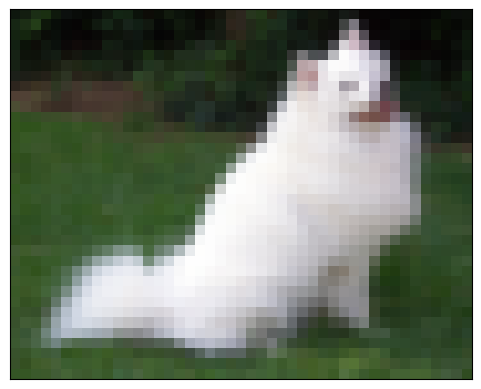

In [5]:
transforms = v2.Compose(
    [
        v2.ToImage(),
        v2.ToDtype(torch.uint8, scale=True),
        v2.RandomHorizontalFlip(p=1.0),
        v2.Resize(size=(36,), max_size=None),
    ]
)
out = transforms(img)
plt.xticks([])
plt.yticks([])
plt.imshow(out.permute(1, 2, 0).numpy())

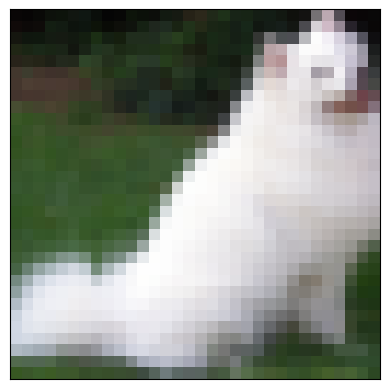

In [6]:
transforms = v2.Compose(
    [
        v2.ToImage(),
        v2.ToDtype(torch.uint8, scale=True),
        v2.RandomHorizontalFlip(p=1.0),
        v2.Resize(size=36, max_size=None),
        v2.CenterCrop(size=32),
    ]
)
out = transforms(img)
plt.xticks([])
plt.yticks([])
plt.imshow(out.permute(1, 2, 0).numpy())

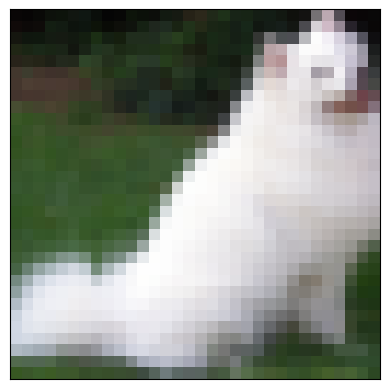

In [14]:
transforms = v2.Compose(
    [
        v2.ToImage(),
        v2.ToDtype(torch.uint8, scale=True),
        v2.RandomHorizontalFlip(p=1.0),
        v2.Resize(size=36, max_size=None),
        v2.CenterCrop(size=(32, 32)),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=(0.0, 0.0, 0.0), std=(1.0, 1.0, 1.0)),
    ]
)
out = transforms(img)
plt.xticks([])
plt.yticks([])
plt.imshow(out.permute(1, 2, 0).numpy())

<br>
<br>

# Ejemplo

In [15]:
import torch


def exp(model, device, train_loader, test_loader, optimizer, scheduler, epochs=15):
    loss_fn = torch.nn.CrossEntropyLoss()
    for epoch in range(epochs):
        print(f"Epoch {epoch}: train:", end=" ")
        model.train()
        trsize, trbatches, trloss, tracc = 0, 0, 0, 0
        for batch in train_loader:
            X, y = batch["X"].to(device), batch["y"].to(device)
            trsize += len(X)
            trbatches += 1
            pred = model(X)
            loss = loss_fn(pred, y)
            trloss += loss.item()
            tracc += (pred.argmax(1) == y).type(torch.float).sum().item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            scheduler.step()
        trloss /= trbatches
        tracc /= trsize
        print(f"loss {trloss:g} acc {tracc:.2%} test:", end=" ")
        model.eval()
        tesize, tebatches, teloss, teacc = 0, 0, 0, 0
        with torch.no_grad():
            for batch in test_loader:
                X, y = batch["X"].to(device), batch["y"].to(device)
                tesize += len(X)
                tebatches += 1
                pred = model(X)
                teloss += loss_fn(pred, y).item()
                teacc += (pred.argmax(1) == y).type(torch.float).sum().item()
        teloss /= tebatches
        teacc /= tesize
        print(f"loss {teloss:g} acc {teacc:.2%}")